In [64]:
import importlib
import miaw
importlib.reload(miaw)
from miaw import FFNN
import numpy as np
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.utils import check_random_state
from sklearn.metrics import accuracy_score


## Usage

In [65]:
X, y = fetch_openml("mnist_784", version=1, return_X_y=True, as_frame=False)

random_state = check_random_state(0)
permutation = random_state.permutation(X.shape[0])
X = X[permutation]
y = y[permutation]
X = X.reshape((X.shape[0], -1))

encoder = OneHotEncoder(sparse_output=False, categories='auto')
y_encoded = encoder.fit_transform(y.reshape(-1, 1))
# train-test split
X_train, X_val, y_train, y_val = train_test_split(X, y_encoded, test_size=0.2, random_state=42)

In [66]:
miawlenteraModel = FFNN([784,128,64,10], ['relu','relu','softmax'],loss_function='cce', use_rmsnorm=False, reg_type="l2", weight_init='he')

history = miawlenteraModel.fit(X_train, y_train, X_val, y_val, epochs=10, batch_size=64, lr=0.05, verbose=1)

Epoch 1/10: 100%|█████████████████████████████████████████| 56000/56000 [00:00<00:00, 113815.82it/s]


Epoch 1 Completed, Train Loss: 1.8210, Val Loss:0.7601


Epoch 2/10: 100%|█████████████████████████████████████████| 56000/56000 [00:00<00:00, 118905.61it/s]


Epoch 2 Completed, Train Loss: 0.5842, Val Loss:0.5475


Epoch 3/10: 100%|█████████████████████████████████████████| 56000/56000 [00:00<00:00, 103945.89it/s]


...

Epoch 8 Completed, Train Loss: 0.2439, Val Loss:0.3210


Epoch 9/10: 100%|█████████████████████████████████████████| 56000/56000 [00:00<00:00, 109146.47it/s]


Epoch 9 Completed, Train Loss: 0.2277, Val Loss:0.3087


Epoch 10/10: 100%|████████████████████████████████████████| 56000/56000 [00:00<00:00, 115974.14it/s]


Epoch 10 Completed, Train Loss: 0.2149, Val Loss:0.2992


In [67]:
miaw_pred = miawlenteraModel.predict(X_val)
y_val_labels = np.argmax(y_val, axis=1)
# miaw_pred_labels = np.argmax(miaw_pred, axis=1)


accuracy = accuracy_score(y_val_labels, miaw_pred)
print(f"Accuracy: {accuracy * 100:.2f}%")


Accuracy: 92.39%


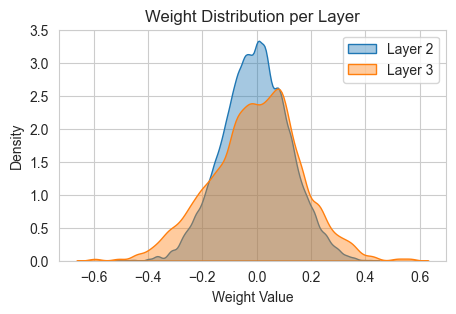

AttributeError: 'Layer' object has no attribute 'dW'

<Figure size 500x300 with 0 Axes>

In [68]:
miawlenteraModel.plot_weight_distribution([1,2])
miawlenteraModel.plot_gradient_distribution([1,2])
miawlenteraModel.plot_loss_history(history)

In [ ]:
miawlenteraModel.save('./models/new-noauto.json')

In [ ]:
testload = FFNN.load('./models/new-noauto.json')

miaw_p = testload.predict(X_val)
y_val_labels = np.argmax(y_val,axis=1)
miaw_pred_labels = np.argmax(miaw_p, axis=1)

accuracy_new = accuracy_score(y_val_labels,miaw_pred_labels)
print(f"Accuracy: {accuracy_new * 100:.2f}%")



Accuracy: 91.51%


In [ ]:
print(history)

{'train_loss': [np.float64(1.6052547209287529), np.float64(0.6521147537023916), np.float64(0.5087713568116594), np.float64(0.43336590395395147), np.float64(0.3822180108446402), np.float64(0.3419250360891706), np.float64(0.313131762119023), np.float64(0.28954895081082743), np.float64(0.27112823156536486), np.float64(0.2563747370129571)], 'val_loss': [np.float64(0.8099198351443412), np.float64(0.6028494769918604), np.float64(0.5066712613400949), np.float64(0.45018421904564204), np.float64(0.42036082997223595), np.float64(0.3819821919771226), np.float64(0.3721066421789023), np.float64(0.3621413159336413), np.float64(0.34134236263807655), np.float64(0.3267279016964207)]}
